## Import

In [1]:
import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:1'

%load_ext autoreload
%autoreload 2

## Experiment settings

In [2]:
mi_level = "mid"
mi_array = {'low':1, 'mid':3, 'high':7, 'very_high':9}
latent = False

mi = mi_array[mi_level]

## Data generation

image size torch.Size([10000, 16, 16]) torch.Size([10000, 16, 16])
data size torch.Size([10000, 256]) torch.Size([10000, 256])


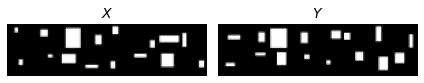

In [4]:
from image import image_dataset

X, Y = image_dataset.generate_rectangle_plot(mi=mi, n_samples=10000, device=device)

n, d = X.size()[0], 2*X.size()[1]

image_dataset.visualize_images(X, Y)

## Dimensionality reduction

In [11]:
from dr.Autoencoder import Autoencoder
from utils import utils_os


d_array = [4, 8, 16, 32, 64]
mse_array = {}


for latent in d_array:


    # [A]. Train autoencoder to compress data
    ae = Autoencoder(x_dim=d//2, y_dim=d//2, latent_size=latent, alpha=1, lam=0)

    ae.to(device)
    X, Y = X.to(device).float(), Y.to(device).float()
    ae.learn(X, Y)

    XX, YY = ae.encode(X, Y)
    XX, YY = XX.clone().detach(), YY.clone().detach()
    X_rec, Y_rec = ae.decode(XX, YY)
    
    # [B]. calculate reconstruction loss
    loss_x = ae.rec_loss(X_rec, X, normalize=True).item()
    loss_y = ae.rec_loss(Y_rec, Y, normalize=True).item()
    
    mse_array[latent] = (loss_x, loss_y)

    print('d=', latent, 'mse=', mse_array[latent])

finished: t= 0 loss= 0.3266098201274872 loss val= 0.31402161717414856 best val loss= 0.31402161717414856 best t= 0
finished: t= 101 loss= 0.004512442275881767 loss val= 0.0050271241925656796 best val loss= 0.0050271241925656796 best t= 101
finished: t= 202 loss= 0.002870510332286358 loss val= 0.0032612341456115246 best val loss= 0.003047200385481119 best t= 197
finished: t= 303 loss= 0.0017860960215330124 loss val= 0.0022441325709223747 best val loss= 0.0022441325709223747 best t= 303
finished: t= 404 loss= 0.0017009438015520573 loss val= 0.0021637575700879097 best val loss= 0.0018238641787320375 best t= 401
finished: t= 505 loss= 0.0012227257248014212 loss val= 0.0016026673838496208 best val loss= 0.0016026673838496208 best t= 505
finished: t= 606 loss= 0.0009945188648998737 loss val= 0.0014528139727190137 best val loss= 0.0014339361805468798 best t= 592
finished: t= 707 loss= 0.0010249473853036761 loss val= 0.0014624953037127852 best val loss= 0.0013174129417166114 best t= 700
finish

In [6]:
from dr.Autoencoder import Autoencoder
from utils import utils_os


latent = 16

# [A]. Train autoencoder to compress data
ae = Autoencoder(x_dim=d//2, y_dim=d//2, latent_size=latent, alpha=1, lam=0)

ae.to(device)
X, Y = X.to(device).float(), Y.to(device).float()
ae.learn(X, Y)


# [B]. compress data and visualize
XX, YY = ae.encode(X, Y)
XX, YY = XX.clone().detach(), YY.clone().detach()
X_rec, Y_rec = ae.decode(XX, YY)
    
image_dataset.visualize_images(XX, YY)

finished: t= 0 loss= 0.3025566339492798 loss val= 0.31740602850914 best val loss= 0.31740602850914 best t= 0
finished: t= 101 loss= 0.001871251268312335 loss val= 0.002469850704073906 best val loss= 0.002469850704073906 best t= 101
finished: t= 202 loss= 0.0011699693277478218 loss val= 0.0016711007338017225 best val loss= 0.001636039698496461 best t= 196
finished: t= 303 loss= 0.0007832603296265006 loss val= 0.0013463647337630391 best val loss= 0.001232964568771422 best t= 294
finished: t= 404 loss= 0.0005694578285329044 loss val= 0.0011020475067198277 best val loss= 0.001065990305505693 best t= 382
finished: t= 505 loss= 0.0005458947271108627 loss val= 0.0009775878861546516 best val loss= 0.0009309017332270741 best t= 489
finished: t= 606 loss= 0.0004992689937353134 loss val= 0.0009749780874699354 best val loss= 0.0008738997275941074 best t= 574
finished: t= 707 loss= 0.0005207068170420825 loss val= 0.0009273986797779799 best val loss= 0.0008067683083936572 best t= 700
finished: t= 80

RuntimeError: shape '[10000, 1, 16, 16]' is invalid for input of size 160000

<Figure size 432x288 with 0 Axes>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


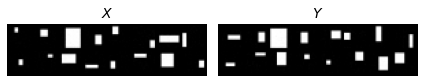

In [7]:
X_rec, Y_rec = ae.decode(XX, YY)
    
X_rec, Y_rec = X_rec.reshape(len(X_rec), 16, 16).detach().cpu(), Y_rec.reshape(len(Y_rec), 16, 16).detach().cpu()

image_dataset.visualize_images(X_rec, Y_rec)